In [ ]:
!pip install pandas -q
!pip install seaborn  -q

In [6]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


### EDA 

In [ ]:
df = pd.read_csv("data/compustat.csv")

print(df.shape)

df.head()

In [ ]:
df['datadate'] = pd.to_datetime(df['datadate'])

df = df.sort_values(['gvkey', 'datadate'])

# year-quarter index
df['year'] = df['datadate'].dt.year
df['quarter'] = df['datadate'].dt.quarter


In [ ]:
print(df.duplicated().sum(), "duplicate rows found and deleted")
df = df.drop_duplicates(subset=['gvkey', 'datadate'])

In [12]:
obs_per_firm = df.groupby('gvkey')['datadate'].count()

# Keep firms with at least 12 quarters (3 years)
valid_firms = obs_per_firm[obs_per_firm >= 12].index
df = df[df['gvkey'].isin(valid_firms)]


In [ ]:
targets = ['oancfy', 'cheq']

df[targets].isna().mean()

oancfy    0.337817
cheq      0.316685
dtype: float64

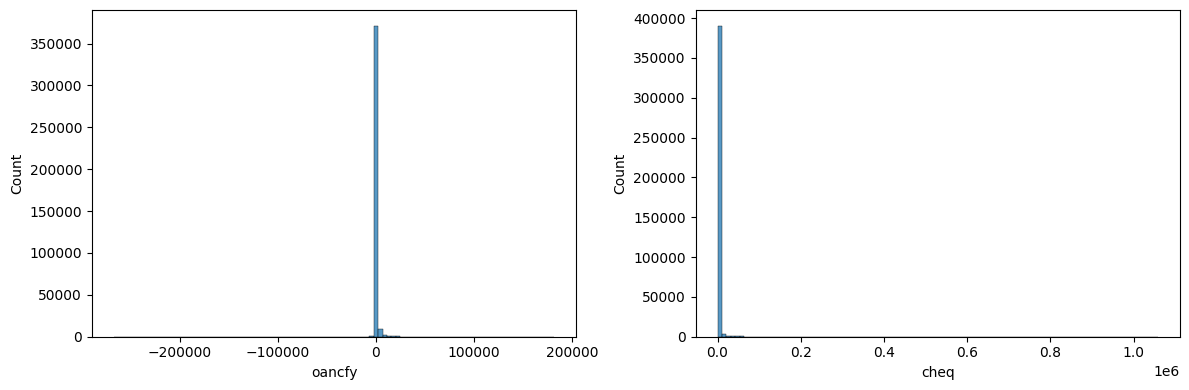

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['oancfy'], bins=100, ax=axes[0])
sns.histplot(df['cheq'], bins=100, ax=axes[1])
plt.tight_layout()


In [17]:
missing = df.isna().mean().sort_values(ascending=False)

missing.head(15)

findltq    0.997649
udoltq     0.988634
scstkcy    0.973893
deraltq    0.890139
derlltq    0.868834
cshopq     0.684295
xrdq       0.680582
xaccq      0.665951
ipodate    0.584371
dd1q       0.529537
npq        0.475842
lltq       0.474066
drcq       0.473048
ivltq      0.460825
wcapq      0.450105
dtype: float64

<Axes: >

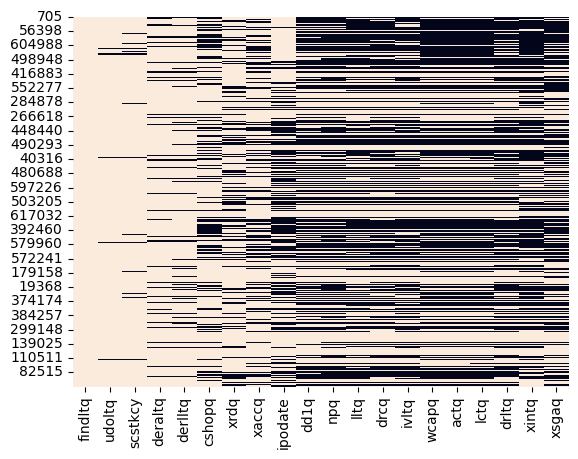

In [18]:
sns.heatmap(df[missing.index[:20]].isna(), cbar=False)